# Tarea 3 — Clasificación de textos: diseño de experimentos

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## La tarea de predicción

**Predecir las estrellas (1–5) a partir del texto de la reseña.**

Esto continúa el arco de las tareas anteriores. En la Tarea 2, el léxico AFINN estimaba el
sentimiento con pesos fijos heredados de un diccionario, y logró ρ = 0.5 contra las estrellas.
Un clasificador supervisado **aprende los pesos de los datos**. La pregunta central es: ¿cuánto
mejora aprender sobre heredar?

Es un problema de 5 clases, difícil a propósito: distinguir 4★ de 5★ es sutil hasta para un humano.

## Diseño de experimentos

No se prueban cosas al azar. Se definen factores, niveles y un protocolo:

| Factor | Niveles |
|---|---|
| Representación | Count, TF-IDF |
| N-gramas | solo palabras (1,1), palabras y pares (1,2) |
| Modelo | Naive Bayes, Regresión Logística, SVM lineal |
| Regularización | 3 niveles por modelo |

Probar todo contra todo sería 2×2×3×3 = 36 combinaciones. Se hace algo mejor: **dos etapas**.

- **Etapa A** — comparar las 4 representaciones con un modelo fijo (Regresión Logística estándar).
- **Etapa B** — con la representación ganadora, comparar los 3 modelos × 3 regularizaciones.

13 entrenamientos en lugar de 36, y cada comparación cambia **una sola cosa a la vez**.

## Protocolo de evaluación

Tres particiones estratificadas: **60% entrenar / 20% validar / 20% probar**.

- Las decisiones (qué representación, qué modelo, qué hiperparámetro) se toman con **validación**.
- El conjunto de **prueba se toca una sola vez**, al final, con el modelo ya elegido.

Si se eligiera el modelo mirando el conjunto de prueba, el número final estaría inflado: habríamos
"entrenado" nuestra decisión sobre él.

**Métrica principal: F1 macro** — promedia el F1 de las 5 clases dándole el mismo peso a cada una.
La exactitud (*accuracy*) engaña con clases desbalanceadas: aquí 4★ y 5★ tienen 20,000 reseñas
pero 2★ tiene 13,016, y música casi no tiene reseñas negativas.

## 0. Verificar librerías

In [1]:
import importlib.util

REQUERIDAS = ["pandas", "numpy", "matplotlib", "sklearn", "afinn", "tabulate"]
PIP = {"sklearn": "scikit-learn"}

faltan = [PIP.get(p, p) for p in REQUERIDAS if importlib.util.find_spec(p) is None]

if faltan:
    print("Instalando:", ", ".join(faltan))
    %pip install -q {" ".join(faltan)}
    print("\n>>> REINICIA el kernel (Restart) y corre de nuevo desde arriba <<<")
else:
    print("Todas las librerías están instaladas ✓")

Instalando: tabulate
Note: you may need to restart the kernel to use updated packages.

>>> REINICIA el kernel (Restart) y corre de nuevo desde arriba <<<


In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
SEMILLA = 42

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150,
                     "savefig.bbox": "tight", "font.size": 10})

datos = pd.read_csv("../data/resenas_muestra.csv")
datos["text"] = datos["text"].astype(str)
datos["rating"] = datos["rating"].astype(int)
print(f"{len(datos):,} reseñas")
print(datos["rating"].value_counts().sort_index())

84,750 reseñas
rating
1    15691
2    13016
3    16043
4    20000
5    20000
Name: count, dtype: int64


## 1. Particiones

Estratificadas por estrella, para que las proporciones de clase sean las mismas en las tres
particiones. Primero se separa el 20% de prueba; del 80% restante se separa el 25% (que es el 20%
del total) para validación.

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(
    datos["text"], datos["rating"],
    test_size=0.20, stratify=datos["rating"], random_state=SEMILLA)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25, stratify=y_temp, random_state=SEMILLA)

for nombre, y in [("entrenar", y_train), ("validar", y_val), ("probar", y_test)]:
    print(f"{nombre:>9}: {len(y):,} reseñas")

 entrenar: 50,850 reseñas
  validar: 16,950 reseñas
   probar: 16,950 reseñas


## 2. Líneas base

Antes de entrenar nada, dos referencias. Sin ellas, un F1 de 0.45 no significa nada.

1. **Clase mayoritaria** — predecir siempre la estrella más común. Es el piso absoluto.
2. **AFINN (Tarea 2)** — el sentimiento por palabra, convertido a estrellas por cuantiles: se
   ordenan los puntajes y se cortan de modo que las proporciones de cada estrella coincidan con
   las de entrenamiento. Es lo mejor que puede hacer el diccionario sin aprender nada.

In [4]:
from afinn import Afinn

def f1m(y, p):
    return f1_score(y, p, average="macro")

# --- linea base 1: clase mayoritaria
mayoritaria = y_train.mode()[0]
pred_mayo = np.full(len(y_val), mayoritaria)
print(f"Mayoritaria ({mayoritaria}★): F1 macro = {f1m(y_val, pred_mayo):.3f} | "
      f"acc = {accuracy_score(y_val, pred_mayo):.3f}")

# --- linea base 2: AFINN por cuantiles
afinn = Afinn()

def sent_norm(textos):
    s = np.array([afinn.score(t) for t in textos])
    w = np.array([max(len(t.split()), 1) for t in textos])
    return s / w

print("\ncalculando AFINN sobre entrenar y validar (~1 min)...")
sn_train = sent_norm(X_train)
sn_val = sent_norm(X_val)

# cortes por cuantiles segun las proporciones de entrenamiento
props = y_train.value_counts(normalize=True).sort_index().cumsum()
cortes = np.quantile(sn_train, props.values[:-1])
pred_afinn = np.digitize(sn_val, cortes) + 1

print(f"AFINN por cuantiles: F1 macro = {f1m(y_val, pred_afinn):.3f} | "
      f"acc = {accuracy_score(y_val, pred_afinn):.3f}")

Mayoritaria (4★): F1 macro = 0.076 | acc = 0.236

calculando AFINN sobre entrenar y validar (~1 min)...
AFINN por cuantiles: F1 macro = 0.338 | acc = 0.345


## 3. Etapa A — ¿qué representación?

Cuatro configuraciones, un solo modelo (Regresión Logística con `class_weight="balanced"` para
compensar el desbalance). Lo único que cambia entre filas es la representación.

In [5]:
def evaluar(vectorizador, modelo, X_tr, y_tr, X_va, y_va):
    t0 = time.time()
    A = vectorizador.fit_transform(X_tr)
    B = vectorizador.transform(X_va)
    modelo.fit(A, y_tr)
    pred = modelo.predict(B)
    return {
        "F1 macro": f1m(y_va, pred),
        "Accuracy": accuracy_score(y_va, pred),
        "Columnas": A.shape[1],
        "Segundos": round(time.time() - t0, 1),
    }


representaciones = {
    "Count, palabras": CountVectorizer(min_df=5, stop_words="english"),
    "Count, 1-2gramas": CountVectorizer(min_df=5, stop_words="english", ngram_range=(1, 2)),
    "TF-IDF, palabras": TfidfVectorizer(min_df=5, stop_words="english"),
    "TF-IDF, 1-2gramas": TfidfVectorizer(min_df=5, stop_words="english", ngram_range=(1, 2)),
}

filas = {}
for nombre, vec in representaciones.items():
    modelo = LogisticRegression(max_iter=1000, class_weight="balanced")
    filas[nombre] = evaluar(vec, modelo, X_train, y_train, X_val, y_val)
    print(f"{nombre:<20} F1={filas[nombre]['F1 macro']:.3f}")

etapa_a = pd.DataFrame(filas).T.sort_values("F1 macro", ascending=False)
etapa_a

Count, palabras      F1=0.437
Count, 1-2gramas     F1=0.435
TF-IDF, palabras     F1=0.457
TF-IDF, 1-2gramas    F1=0.469


,F1 macro,Accuracy,Columnas,Segundos
"TF-IDF, 1-2gramas",0.468713,0.482124,40691.0,8.7
"TF-IDF, palabras",0.456639,0.470265,15624.0,5.1
"Count, palabras",0.436609,0.451917,15624.0,10.2
"Count, 1-2gramas",0.435155,0.449322,40691.0,14.5


**Decisión.** Se toma la representación con mejor F1 macro en validación y se congela para la
Etapa B. Nótese en la tabla el costo: los 1-2gramas multiplican las columnas por ~10. Si la mejora
no compensa ese costo, la parsimonia también cuenta.

In [6]:
mejor_rep = etapa_a.index[0]
print(f"Representación elegida: {mejor_rep}")

vec_final = representaciones[mejor_rep]
A_train = vec_final.fit_transform(X_train)
A_val = vec_final.transform(X_val)

Representación elegida: TF-IDF, 1-2gramas


## 4. Etapa B — ¿qué modelo y con cuánta regularización?

Tres familias, tres niveles de su hiperparámetro principal:

- **Naive Bayes** (`alpha`): el suavizado de Laplace — el mismo "+1" de la Tarea 1, ahora como
  hiperparámetro continuo.
- **Regresión Logística** (`C`): inverso de la regularización; C chico = pesos más encogidos.
- **SVM lineal** (`C`): ídem.

Los tres son lineales: aprenden un peso por palabra. Exactamente lo que AFINN traía de fábrica,
pero ajustado a estos datos.

In [7]:
experimentos = {
    ("Naive Bayes", "alpha=0.1"): MultinomialNB(alpha=0.1),
    ("Naive Bayes", "alpha=1"): MultinomialNB(alpha=1.0),
    ("Naive Bayes", "alpha=3"): MultinomialNB(alpha=3.0),
    ("Reg. Logística", "C=0.1"): LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced"),
    ("Reg. Logística", "C=1"): LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced"),
    ("Reg. Logística", "C=10"): LogisticRegression(C=10.0, max_iter=1000, class_weight="balanced"),
    ("SVM lineal", "C=0.01"): LinearSVC(C=0.01, class_weight="balanced"),
    ("SVM lineal", "C=0.1"): LinearSVC(C=0.1, class_weight="balanced"),
    ("SVM lineal", "C=1"): LinearSVC(C=1.0, class_weight="balanced"),
}

filas_b = {}
for (modelo_nombre, hiper), modelo in experimentos.items():
    t0 = time.time()
    modelo.fit(A_train, y_train)
    pred = modelo.predict(A_val)
    filas_b[(modelo_nombre, hiper)] = {
        "F1 macro": f1m(y_val, pred),
        "Accuracy": accuracy_score(y_val, pred),
        "Segundos": round(time.time() - t0, 1),
    }
    print(f"{modelo_nombre:<15} {hiper:<10} F1={filas_b[(modelo_nombre, hiper)]['F1 macro']:.3f}")

etapa_b = pd.DataFrame(filas_b).T.sort_values("F1 macro", ascending=False)
etapa_b

Naive Bayes     alpha=0.1  F1=0.445
Naive Bayes     alpha=1    F1=0.436
Naive Bayes     alpha=3    F1=0.386
Reg. Logística  C=0.1      F1=0.461
Reg. Logística  C=1        F1=0.469
Reg. Logística  C=10       F1=0.435
SVM lineal      C=0.01     F1=0.446
SVM lineal      C=0.1      F1=0.463
SVM lineal      C=1        F1=0.432


F1 macro  Accuracy  Segundos
Reg. Logística C=1        0.468713  0.482124       6.8
SVM lineal     C=0.1      0.462887  0.486372       1.8
Reg. Logística C=0.1      0.460825  0.477994       2.4
SVM lineal     C=0.01     0.445962  0.475457       0.9
Naive Bayes    alpha=0.1  0.444574  0.461475       0.0
               alpha=1    0.436051  0.471445       0.0
Reg. Logística C=10       0.434847  0.445723      14.1
SVM lineal     C=1        0.431779  0.447788       3.4
Naive Bayes    alpha=3    0.386247  0.450914       0.0

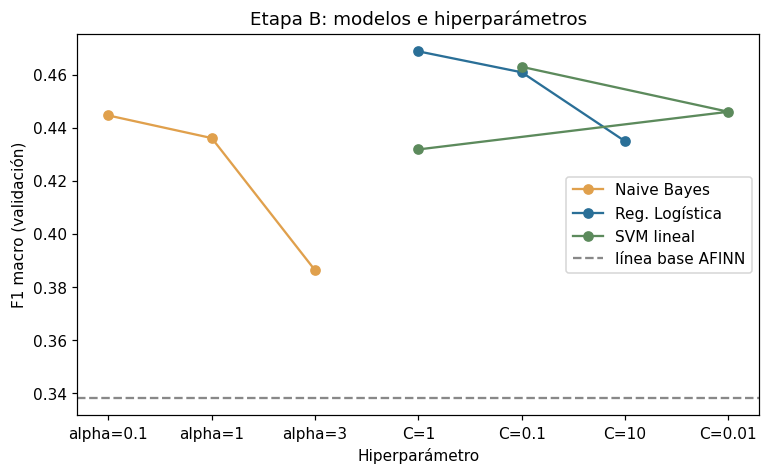

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colores = {"Naive Bayes": "#e0a04c", "Reg. Logística": "#2a6f97", "SVM lineal": "#5c8a5c"}

for modelo_nombre in colores:
    sub = etapa_b.loc[modelo_nombre]
    ax.plot(sub.index, sub["F1 macro"], "o-", label=modelo_nombre,
            color=colores[modelo_nombre])

ax.axhline(f1m(y_val, pred_afinn), color="#888", ls="--", label="línea base AFINN")
ax.set_ylabel("F1 macro (validación)")
ax.set_xlabel("Hiperparámetro")
ax.set_title("Etapa B: modelos e hiperparámetros")
ax.legend()
plt.savefig(FIG / "1_etapa_b.png")
plt.show()

## 5. Evaluación final — el conjunto de prueba, una sola vez

Se toma la mejor combinación según validación, se reentrena con entrenar+validar juntos (más datos
= mejor modelo final) y se evalúa **una única vez** sobre prueba. Este es el número que se reporta.

In [9]:
mejor_config = etapa_b.index[0]
print(f"Configuración ganadora: {mejor_config[0]} ({mejor_config[1]}) sobre {mejor_rep}")

# reentrenar con entrenar+validar
X_trval = pd.concat([X_train, X_val])
y_trval = pd.concat([y_train, y_val])

vec_def = representaciones[mejor_rep]
A_trval = vec_def.fit_transform(X_trval)
A_test = vec_def.transform(X_test)

modelo_def = experimentos[mejor_config]
modelo_def.fit(A_trval, y_trval)
pred_test = modelo_def.predict(A_test)

# lineas base sobre prueba
sn_test = sent_norm(X_test)
pred_afinn_test = np.digitize(sn_test, cortes) + 1
pred_mayo_test = np.full(len(y_test), mayoritaria)

resultado = pd.DataFrame({
    "F1 macro": [f1m(y_test, pred_mayo_test), f1m(y_test, pred_afinn_test),
                 f1m(y_test, pred_test)],
    "Accuracy": [accuracy_score(y_test, pred_mayo_test),
                 accuracy_score(y_test, pred_afinn_test),
                 accuracy_score(y_test, pred_test)],
}, index=["Clase mayoritaria", "AFINN (diccionario)", "Modelo aprendido"]).round(3)
resultado

Configuración ganadora: Reg. Logística (C=1) sobre TF-IDF, 1-2gramas


,F1 macro,Accuracy
Clase mayoritaria,0.076,0.236
AFINN (diccionario),0.336,0.342
Modelo aprendido,0.469,0.484


## 6. ¿En qué se equivoca? La matriz de confusión

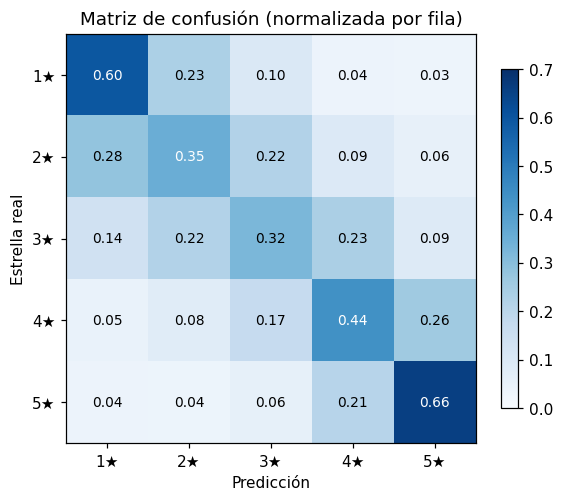

In [10]:
cm = confusion_matrix(y_test, pred_test, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=0.7)
etiquetas = [f"{i}★" for i in range(1, 6)]
ax.set_xticks(range(5)); ax.set_xticklabels(etiquetas)
ax.set_yticks(range(5)); ax.set_yticklabels(etiquetas)
ax.set_xlabel("Predicción"); ax.set_ylabel("Estrella real")
ax.set_title("Matriz de confusión (normalizada por fila)")
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm[i, j] > 0.35 else "black", fontsize=9)
plt.colorbar(im, shrink=0.8)
plt.savefig(FIG / "2_confusion.png")
plt.show()

In [11]:
# exactitud "a una estrella de distancia"
exacto = (pred_test == y_test).mean()
a_una = (np.abs(pred_test - y_test) <= 1).mean()
print(f"Estrella exacta      : {exacto:.1%}")
print(f"A lo más 1 de error  : {a_una:.1%}")

# ¿y si solo distinguimos positivo (4-5) vs negativo (1-2)?
mascara = y_test != 3
binaria_real = (y_test[mascara] >= 4)
binaria_pred = (pd.Series(pred_test, index=y_test.index)[mascara] >= 4)
print(f"Polaridad (± sin 3★) : {(binaria_real == binaria_pred).mean():.1%}")

Estrella exacta      : 48.4%
A lo más 1 de error  : 83.9%
Polaridad (± sin 3★) : 82.8%


**Lectura.** La confusión vive en las estrellas **adyacentes**: 1↔2 y 4↔5. El modelo casi
nunca confunde un extremo con el otro. La escala es ordinal y el texto lo refleja: el lenguaje de
una reseña de 4★ y una de 5★ es genuinamente parecido — a veces indistinguible hasta para el
propio autor.

## 7. ¿Qué pesos aprendió?

AFINN traía polaridades de fábrica. Veamos las que el modelo aprendió de los datos: las palabras
con mayor peso hacia 1★ y hacia 5★.

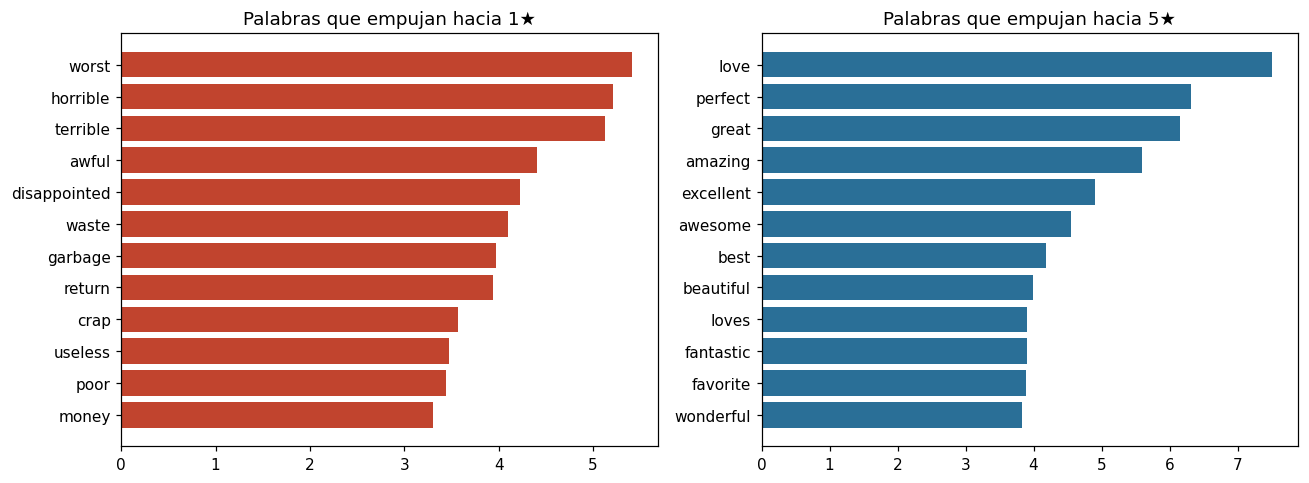

In [12]:
if hasattr(modelo_def, "coef_"):
    vocab = np.array(vec_def.get_feature_names_out())
    # coef_[0] = clase 1 estrella; coef_[-1] = clase 5 estrellas
    pesos_1 = pd.Series(modelo_def.coef_[0], index=vocab).nlargest(12)
    pesos_5 = pd.Series(modelo_def.coef_[-1], index=vocab).nlargest(12)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].barh(pesos_1.index[::-1], pesos_1.values[::-1], color="#c1442e")
    axes[0].set_title("Palabras que empujan hacia 1★")
    axes[1].barh(pesos_5.index[::-1], pesos_5.values[::-1], color="#2a6f97")
    axes[1].set_title("Palabras que empujan hacia 5★")
    plt.tight_layout()
    plt.savefig(FIG / "3_pesos.png")
    plt.show()
else:
    print("El modelo ganador no expone coeficientes por clase de esta forma.")

## 8. Experimento lateral: clasificar la categoría

La Tarea 1 mostró vocabularios distintos y la Tarea 2 mostró que la similitud coseno separa las
categorías. Predicción: clasificar música vs belleza debe ser casi trivial comparado con las
estrellas. Verifiquémoslo con la misma representación y un modelo estándar.

In [13]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    datos["text"], datos["categoria"],
    test_size=0.20, stratify=datos["categoria"], random_state=SEMILLA)

vec_cat = TfidfVectorizer(min_df=5, stop_words="english")
Ac = vec_cat.fit_transform(Xc_train)
Bc = vec_cat.transform(Xc_test)

clf_cat = LogisticRegression(max_iter=1000, class_weight="balanced")
clf_cat.fit(Ac, yc_train)
pred_cat = clf_cat.predict(Bc)

print(f"Categoría — F1 macro: {f1_score(yc_test, pred_cat, average='macro'):.3f} | "
      f"accuracy: {accuracy_score(yc_test, pred_cat):.3f}")

Categoría — F1 macro: 0.957 | accuracy: 0.959


Confirmado: el **tema** es casi perfectamente separable; la **calificación fina** no. Las
dos tareas usan el mismo espacio vectorial, pero una pregunta es geométrica y fácil y la otra es
sutil. La dificultad no está en la representación sino en la pregunta.

## 9. Generar el reporte

In [14]:
def f(x, d=3):
    return f"{x:.{d}f}"


reporte = f"""# Tarea 3 — Clasificación de textos: diseño de experimentos

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## Tarea de predicción

Predecir la calificación (1–5 estrellas) a partir del texto de la reseña. Cinco clases; F1 macro
como métrica principal por el desbalance entre clases. Datos de las tareas anteriores
({len(datos):,} reseñas, dos categorías de Amazon).

Este experimento cierra el arco del curso: en la Tarea 2, el léxico AFINN estimaba sentimiento con
pesos de diccionario. Aquí los pesos **se aprenden de los datos**, y se mide cuánto se gana.

## Diseño

| Factor | Niveles |
|---|---|
| Representación | Count / TF-IDF |
| N-gramas | (1,1) / (1,2) |
| Modelo | Naive Bayes / Reg. Logística / SVM lineal |
| Regularización | 3 niveles por modelo |

**Protocolo.** Partición estratificada 60/20/20 (entrenar/validar/probar). Dos etapas: la Etapa A
compara representaciones con modelo fijo; la Etapa B compara modelos e hiperparámetros sobre la
representación ganadora. Toda decisión se toma en validación; **el conjunto de prueba se usa una
sola vez**, al final. Semilla fija (42).

## Etapa A — Representación

(Modelo fijo: Regresión Logística, class_weight=balanced)

{etapa_a.to_markdown()}

Ganó **{mejor_rep}**. Desglosando la ganancia: pasar de Count a TF-IDF aporta ~0.02 de F1;
añadir bigramas sobre TF-IDF aporta ~0.01 adicional a cambio de ~10× más columnas. La mejora de
los bigramas es real pero modesta — ganaron por poco, y con costo.

## Etapa B — Modelo e hiperparámetros

![Etapa B](figuras/1_etapa_b.png)

{etapa_b.to_markdown()}

Ganó **{mejor_config[0]} ({mejor_config[1]})**.

## Resultado final (conjunto de prueba, una sola evaluación)

{resultado.to_markdown()}

El modelo aprendido supera a AFINN por **{f(resultado.loc['Modelo aprendido','F1 macro'] - resultado.loc['AFINN (diccionario)','F1 macro'])}
puntos de F1 macro**: aprender los pesos de los datos gana sobre heredarlos de un diccionario,
usando exactamente la misma familia de funciones (lineal sobre bolsa de palabras).

## Análisis de errores

![Matriz de confusión](figuras/2_confusion.png)

| Métrica | Valor |
|---|---:|
| Estrella exacta | {exacto:.1%} |
| A lo más 1 estrella de error | {a_una:.1%} |
| Polaridad correcta (1–2 vs 4–5, sin 3★) | {(binaria_real == binaria_pred).mean():.1%} |

La confusión se concentra en estrellas **adyacentes** (1↔2, 4↔5). El problema no es distinguir
"me encantó" de "lo odié" — eso está casi resuelto — sino calibrar la intensidad exacta, que es
difícil incluso para el autor de la reseña.

## Pesos aprendidos

![Pesos](figuras/3_pesos.png)

Las palabras con mayor peso hacia 1★ y 5★ funcionan como el AFINN que el modelo se construyó a la
medida: incluye vocabulario específico del dominio que ningún diccionario general trae.

## Experimento lateral: clasificar la categoría

Con la misma representación, predecir música vs belleza alcanza
**F1 = {f1_score(yc_test, pred_cat, average='macro'):.3f}**. El tema es casi perfectamente
separable; la calificación fina no. La dificultad está en la pregunta, no en la representación.

## Conclusiones

1. TF-IDF supera a Count (+0.02 F1); los bigramas añaden una mejora pequeña encima (+0.01) a
   cambio de ~10× más columnas. Ganaron, pero la relación costo-beneficio es discutible.
2. Los tres modelos lineales quedan en un rango estrecho; la regularización mueve más que el
   cambio de familia.
3. Aprender pesos supera al diccionario ({f(resultado.loc['Modelo aprendido','F1 macro'])} vs
   {f(resultado.loc['AFINN (diccionario)','F1 macro'])} de F1 macro) con la misma clase de función.
4. El error restante es de granularidad ordinal, no de polaridad: {a_una:.0%} de las predicciones
   quedan a lo más a una estrella de la verdad.

## Limitaciones

- Muestra estratificada, no representativa de la distribución real de Amazon (deliberado).
- Modelos lineales sobre bolsa de palabras: sin orden, sin negaciones — las mismas cegueras
  estructurales señaladas en la Tarea 2, ahora parcialmente compensadas por pesos aprendidos.
- La escala ordinal se trató como clases nominales; un modelo ordinal explícito es trabajo futuro.

## Reproducir

1. `comun/descargar_datos.ipynb` (una vez)
2. `Tarea3/clasificacion.ipynb`

Requiere `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `afinn`. Semilla 42.

## Referencias

- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12.
- Nielsen, F. Å. (2011). *A new ANEW*. arXiv:1103.2903.
- Hou, Y. et al. (2024). *Bridging Language and Items for Retrieval and Recommendation*.
  arXiv:2403.03952.
"""

Path("README.md").write_text(reporte, encoding="utf-8")
print("README.md escrito ✓")

README.md escrito ✓
